<a href="https://colab.research.google.com/github/rimakrivis/CNN-DL-ImageClassification/blob/main/Model4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading and Setup**

In this step, I am preparing the project by importing the necessary libraries and loading the images.

1. Imported libraries: Added NumPy for math, Matplotlib for showing images, and TensorFlow for the AI model.

2. Loaded data: Downloaded the CIFAR-10 dataset and split it into training and testing sets.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


# **Data Visualization**
Displaying a grid of sample images to see what the dataset looks like.

1. Defined labels: Created a list of names for each category (like plane, cat, and dog).

2. Plotted images: Used a loop to show 10 examples from each of the 10 classes to see the image quality.

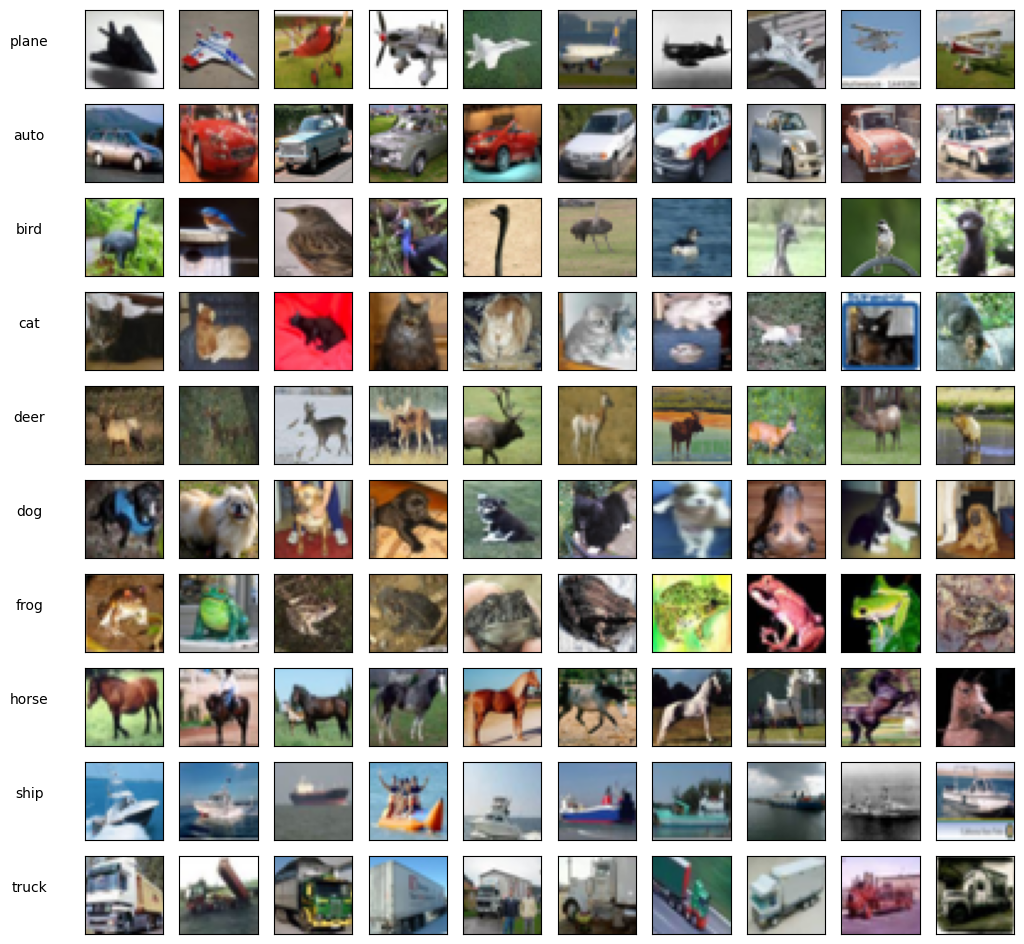

In [3]:
class_names = ['plane', 'auto', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12,12))

for i in range(10):
  indices = np.where(y_train == i)[0]

  for j in range(10):
    plt.subplot(10,10,i*10 + j + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[indices[j]])
    if j == 0:
            # Add class name as label on the left
            plt.ylabel(class_names[i], rotation=0, labelpad=40)

plt.show()



# **Label Encoding**
Converting the category numbers into one-hot vectors to prepare them for the multi-class classification model.

In [4]:
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Original label: {y_train[0]}")
print(f"One-hot form: {y_train_cat[0]}")

Original label: [6]
One-hot form: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


# Image Resizing
Resized the images from 32x32 to 64x64 pixels. Used TensorFlow to upscale the dataset, which helps the deeper layers extract more detailed features.

**Expected Better Recognition**: In previous tests, the model could easily identify a plane versus a cat, but it struggled with similar shapes. By increasing the size, I want to help the model better distinguish between difficult pairs like dog vs. cat or deer vs. bird.

In [5]:
import tensorflow as tf

x_train_64 = tf.image.resize(x_train, (64, 64))
x_test_64 = tf.image.resize(x_test, (64, 64))



## **Data Normalization**
Scaled the pixel values to a range between 0 and 1 to help the model learn faster and more effectively.

In [6]:
# Scale pixel values to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Normalization complete.")
print(f"New pixel range: {x_train.min()} to {x_train.max()}")

Normalization complete.
New pixel range: 0.0 to 1.0


# **Data Augmentation**
It applies random transformations—such as flipping, rotating, and zooming—to training images in real-time, preventing the model from memorizing specific patterns and significantly improving its ability to generalize to new data.

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

print("Data augmentation layer defined successfully.")

Data augmentation layer defined successfully.


# **Model #4: Stability & Regularization**
Model #4 retains the 3-block VGG structure of Model #3 but introduces critical layers to prevent overfitting and ensure training stability.

**Key Improvements** over Model #3:

**Batch Normalization:** Added after every Conv/Dense layer to stabilize gradients and speed up convergence.

**Progressive Dropout (0.2 to 0.5):** Strategically implemented to prevent the model from memorizing the training data.

**Adam Optimizer:** Used at a low learning rate (0.0001) for precise weight updates and better generalization.

In [8]:
from keras.backend import clear_session
clear_session()

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


model_4 = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,650 (4.37 MB)

 Trainable params: 1,143,946 (4.36 MB)

 Non-trainable params: 704 (2.75 KB)

# **Model Compilation & Training**
The model is compiled using the Adam optimizer with a low learning rate 0.00 to ensure stable weight updates. Training is managed by an EarlyStopping callback, which monitors validation loss and halts the process if no improvement is seen for 10 consecutive epochs, preventing overfitting and saving the best model state.

In [20]:
model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_4 = model_4.fit(
    x_train_64,
    y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)

print("\n--- TRAINING COMPLETE ---")

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.8744 - loss: 0.3544 - val_accuracy: 0.8024 - val_loss: 0.6476
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8771 - loss: 0.3479 - val_accuracy: 0.8094 - val_loss: 0.6467
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8764 - loss: 0.3451 - val_accuracy: 0.7676 - val_loss: 0.7951
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8789 - loss: 0.3394 - val_accuracy: 0.8082 - val_loss: 0.6369
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8799 - loss: 0.3358 - val_accuracy: 0.8204 - val_loss: 0.5968
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8808 - loss: 0.3347 - val_accuracy: 0.8234 - val_loss: 0.5760
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8792 - loss: 0.3352 - val_accuracy: 0.8202 - val_loss: 0.5908
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8813 - loss: 0.3358 - val_acc

In [ ]:
model_4.save('model_4.keras')
print("Model saved as model_4.keras")

Model saved as model_4.keras


In [21]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model_4 = load_model('/content/model_4.keras')

print("Model 4 loaded successfully!")

model_4.summary()


Model 4 loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,432,544 (13.09 MB)

 Trainable params: 1,143,946 (4.36 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 2,287,894 (8.73 MB)

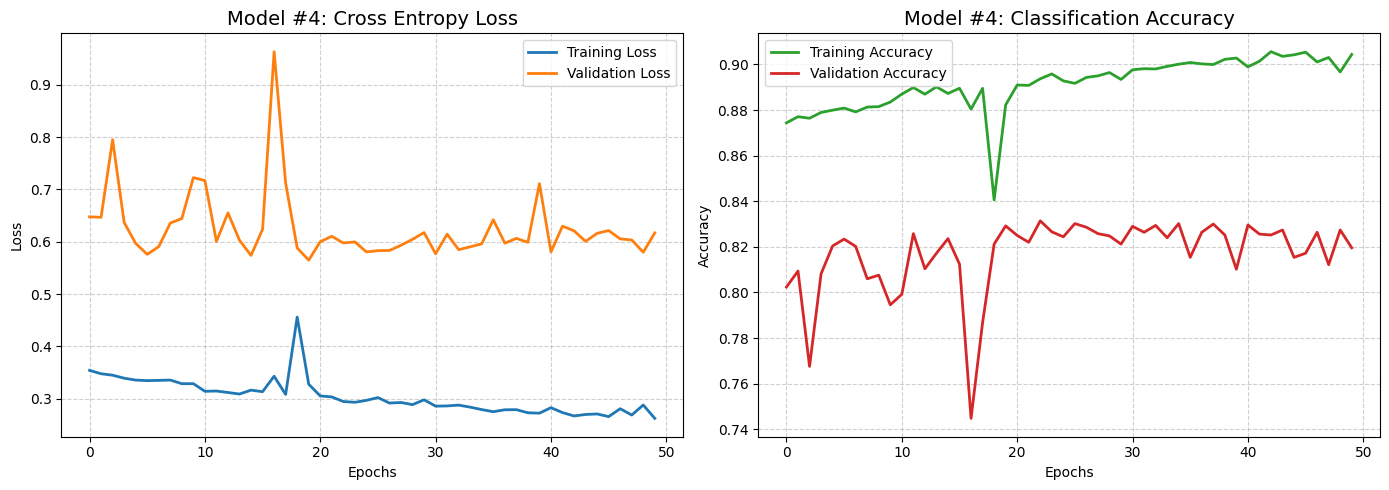

In [22]:
plt.figure(figsize=(14, 5))

# 1. Plot Cross Entropy Loss
plt.subplot(1, 2, 1)
plt.plot(history_4.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history_4.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Model #4: Cross Entropy Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_4.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
plt.title('Model #4: Classification Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Load model for testing data

#  Model Evaluation

We evaluate **Model #4** using 10,000 unseen test images to measure its generalization performance.

**Key Metrics:**
* **Accuracy:** Overall percentage of correct predictions.
* **Precision:** Accuracy of positive predictions (avoiding false alarms).
* **Recall:** Ability to find all actual positive samples.
* **F1-Score:** The balance between Precision and Recall.

In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

try:
    print("Generating predictions...")
    y_pred_probs = model_4.predict(x_test_64)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
                   'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

    print("\n" + "="*60)
    print("         MODEL #4 PERFORMANCE EVALUATION")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=class_names))

    test_loss, test_acc = model_4.evaluate(x_test_64, y_test_cat, verbose=0)

    print("-"*60)
    print(f"FINAL TEST LOSS:     {test_loss:.4f}")
    print(f"FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print("-"*60)

except NameError as e:
    print(f"ERROR: Variable not found. Please check your variable names! \nDetails: {e}")

Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

         MODEL #4 PERFORMANCE EVALUATION
              precision    recall  f1-score   support

    Airplane       0.85      0.74      0.79      1000
  Automobile       0.94      0.88      0.90      1000
        Bird       0.73      0.71      0.72      1000
         Cat       0.63      0.66      0.64      1000
        Deer       0.71      0.82      0.76      1000
         Dog       0.77      0.66      0.71      1000
        Frog       0.84      0.86      0.85      1000
       Horse       0.87      0.82      0.85      1000
        Ship       0.81      0.92      0.86      1000
       Truck       0.84      0.90      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000

------------------------------------------------------------
FINAL TEST LOSS:     0.6463
FINAL TEST ACCURACY: 0.7959 (79.59%)
------

### Model_4: Confusion Matrix Analysis
To visually assess the model's performance across all 10 classes, we generate a **Confusion Matrix**. This allows us to identify specific patterns of misclassification—such as visual similarities between cats and dogs—providing deeper insight beyond the overall accuracy score.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


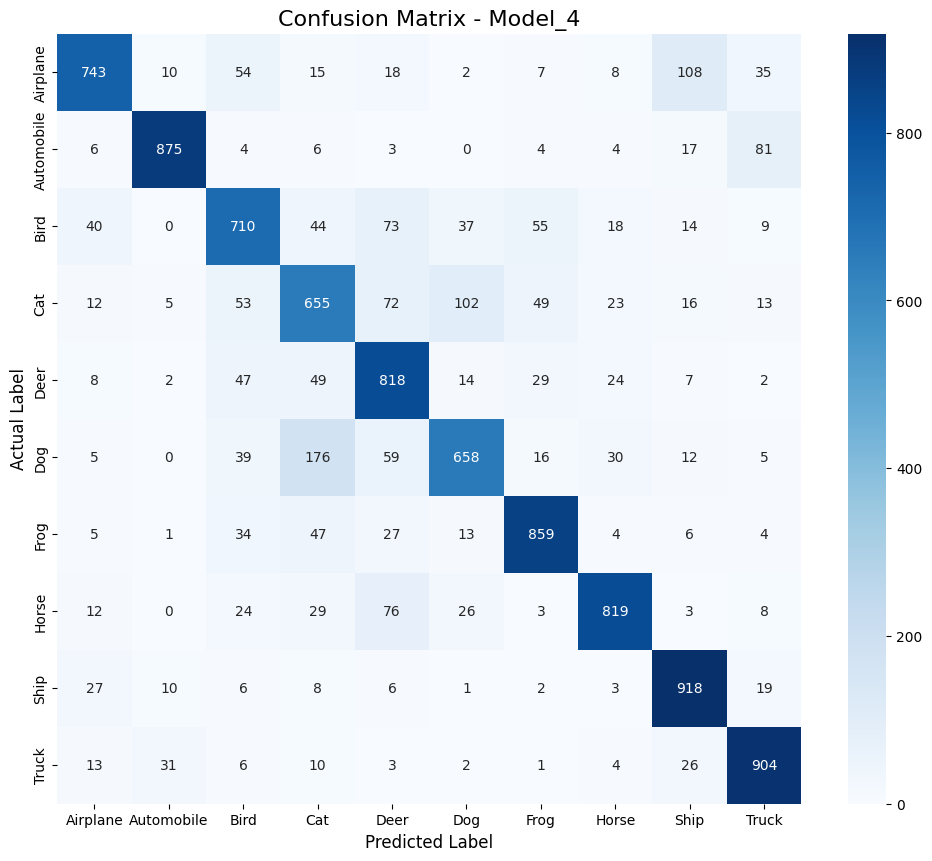

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_pred_probs = model_4.predict(x_test_64)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix - Model_4', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [25]:
t_acc = history_4.history['accuracy'][-1]
t_loss = history_4.history['loss'][-1]
v_acc = history_4.history['val_accuracy'][-1]
v_loss = history_4.history['val_loss'][-1]

print(f"Training Accuracy:   {t_acc:.4f}")
print(f"Training Loss:       {t_loss:.4f}")
print(f"Validation Accuracy: {v_acc:.4f}")
print(f"Validation Loss:     {v_loss:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

Training Accuracy:   0.9044
Training Loss:       0.2626
Validation Accuracy: 0.8196
Validation Loss:     0.6170
Test Accuracy:       0.7959


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Surandame indeksus nuotraukų, kurias modelis suklasifikavo neteisingai
# Lyginame nuspėtas klases (y_pred) su tikrosiomis (y_true)
errors = np.where(y_pred != y_true)[0]
print(f"Total Errors: {len(errors)} out of 10,000 images")

# 2. Sukuriame langą 10-čiai klaidų atvaizduoti
plt.figure(figsize=(16, 8))

for i in range(10):
    idx = errors[i] # Paimame klaidos indeksą
    plt.subplot(2, 5, i + 1)

    # --- SVARBI DALIS ---
    # Naudojame .astype('uint8'), kad pašalintume kablelius ir gražintume 0-255 formatą
    img_to_show = x_test_64[idx].astype('uint8')

    plt.imshow(img_to_show)
    plt.xticks([]) # Paslepiame ašis, kad būtų gražiau
    plt.yticks([])
    plt.grid(False)

    # Ištraukiame pavadinimus
    actual_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]

    # Antraštė: Tikra klasė ir ką modelis "pamanė"
    plt.title(f"True: {actual_label}\nPred: {predicted_label}",
              color='red', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'y_pred' is not defined